# URIEL+ Data Checks: Feature Categories and the Phylogeny/Geography Build Pipeline

This notebook combines two write-ups into one runnable file:

- **Part 1: Feature categories in `features.npz`.** Counts how many of the URIEL+ features
  fall into each category (Syntax, Morphology, Inventory, Phonology) and plots the result.
- **Part 2: The phylogeny/geography build pipeline.** Checks `lang_fam_geo.csv`,
  `uriel_glottocode_map.csv` and the logic of `urielplus_databases.py` against Glottolog's
  own rules and classification.

Every number in the text below is printed by a code cell, so run the notebook top to bottom
(**Run All**) and read the outputs rather than trusting any figure quoted in prose.

**Inputs**

| File | Used in | Default location |
|---|---|---|
| `features.npz` | Part 1, and Part 2 (list of vector languages) | `data/features.npz` (extracted from `data.zip` if needed) |
| `family_features.npz` | Part 2 (list of vector languages), optional | searched for automatically |
| `lang_fam_geo.csv` | Part 2 | `URIELPlus/urielplus/database/urielplus_csvs/` |
| `uriel_glottocode_map.csv` | Part 2 | `URIELPlus/urielplus/database/urielplus_csvs/` |

## 0. Setup

Run this cell first. It imports everything the notebook needs, locates the two CSV files,
and extracts `data.zip` into `data/` if that folder is not already there (same setup as the
Milestone 2 EDA notebook). If your folders are somewhere else, edit `CSV_DIR_CANDIDATES`.

In [1]:
import math
import re
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

# ---- Where the CSVs live (first folder that exists wins) ----
CSV_DIR_CANDIDATES = [
    Path("URIELPlus/urielplus/database/urielplus_csvs"),
    Path("../URIELPlus/urielplus/database/urielplus_csvs"),
    Path(r"C:\Users\alamr\csci3052u-ml-project\URIELPlus\urielplus\database\urielplus_csvs"),
]
CSV_DIR = next((p for p in CSV_DIR_CANDIDATES if p.exists()), None)
if CSV_DIR is None:
    raise FileNotFoundError(
        "Could not find urielplus_csvs. Edit CSV_DIR_CANDIDATES in this cell. Tried:\n  "
        + "\n  ".join(str(p) for p in CSV_DIR_CANDIDATES)
    )

LFG_PATH = CSV_DIR / "lang_fam_geo.csv"
ISO_MAP_PATH = CSV_DIR / "uriel_glottocode_map.csv"

# ---- Feature data: extract data.zip if the data folder is missing ----
DATA_DIR = Path("data")
if not DATA_DIR.exists() and Path("data.zip").exists():
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall(".")

# ---- Figures are saved here ----
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("CSV folder:", CSV_DIR.resolve())
print("features.npz found:", (DATA_DIR / "features.npz").exists())

CSV folder: C:\Users\alamr\csci3052u-ml-project\URIELPlus\urielplus\database\urielplus_csvs
features.npz found: True


### Definitions

- **Glottocode**: an eight-character identifier (format `[0-9a-z]{4}[0-9]{4}`, i.e. four
  letters-or-digits followed by four digits) that the Glottolog project assigns to every
  language, dialect, and language family it catalogues. Example: `ghot1243` is Ghotuo, a
  language spoken in Nigeria (Glottolog, n.d.).
- **Lineage**: the chain of ancestor families a language descends from, root to leaf.
  Example: `Atlantic-Congo, Volta-Congo, Benue-Congo, ...`
- **Glottolog**: the database, maintained at the Max Planck Institute for Evolutionary
  Anthropology, that assigns Glottocodes and maintains the family-tree classification for
  every language in the world (Hammarström et al., 2026).
- **Vector languages**: the languages that actually receive a row in the URIEL+ feature
  matrices. `lang_fam_geo.csv` has many more rows than this.

---
# Part 1: Feature Categories in `features.npz`

`data/features.npz` stores the URIEL+ feature matrix used in the Milestone 2 EDA. Each
feature has a name that begins with a prefix identifying the category it belongs to:

| Prefix | Category |
|---|---|
| `S_` | Syntax |
| `M_` | Morphology |
| `INV_` | Inventory |
| `P_` | Phonology |

## 1.1 Loading the File

An `.npz` file is a bundle of named arrays. Listing its `files` attribute shows what it
contains; the feature names are in the array called `feats`.

In [2]:
# Feature-name prefix -> category
PREFIXES = {"S_": "Syntax", "M_": "Morphology", "INV_": "Inventory", "P_": "Phonology"}

npz_file = np.load(DATA_DIR / "features.npz", allow_pickle=True)
print(f"Arrays in the NPZ file: {npz_file.files}")

features = npz_file["feats"].astype(str)
num_features = len(features)
print(f"Loaded {num_features} features.")

Arrays in the NPZ file: ['data', 'feats', 'langs', 'sources']
Loaded 593 features.


## 1.2 Counting Features by Category

Each feature name is matched against the four prefixes. Any name that matches none of them is
counted under `Other` (and its prefix is printed) so nothing is silently dropped.

In [3]:
counts = Counter()
for name in features:
    for prefix, label in PREFIXES.items():
        if name.startswith(prefix):
            counts[label] += 1
            break
    else:
        counts["Other"] += 1

if counts["Other"]:
    unknown = sorted({n.split("_")[0] + "_" for n in features if not n.startswith(tuple(PREFIXES))})
    print(f"Note: {counts['Other']} features have no known prefix. Prefixes seen: {unknown}")

prefix_of = {label: prefix for prefix, label in PREFIXES.items()}
summary = pd.DataFrame(
    [
        {
            "Category": label,
            "Prefix": prefix_of.get(label, "-"),
            "Features": n,
            "Share (%)": round(n / num_features * 100, 1),
        }
        for label, n in counts.most_common()
    ]
)
print(f"Features counted: {summary['Features'].sum()} / {num_features}")
summary

Features counted: 593 / 593


,Category,Prefix,Features,Share (%)
0,Syntax,S_,307,51.8
1,Inventory,INV_,172,29.0
2,Morphology,M_,85,14.3
3,Phonology,P_,29,4.9


## 1.3 Bar Chart

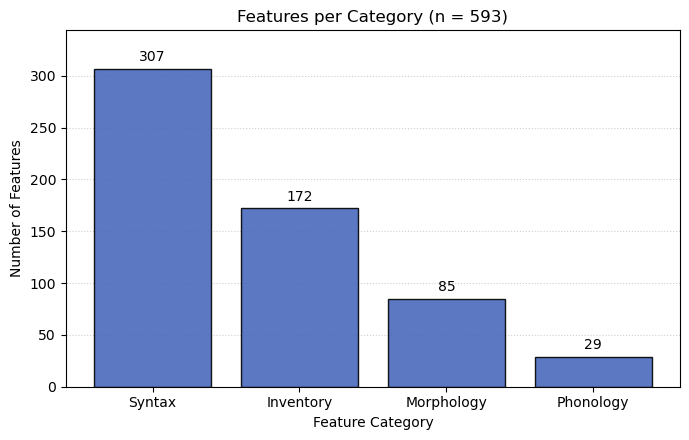

Syntax is the largest category: 307 of 593 features (51.8%); the other categories together have 286.


In [4]:
labels = [label for label, _ in counts.most_common()]   # largest first
values = [counts[label] for label in labels]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, values, color="#4a69bd", edgecolor="black", alpha=0.9)
ax.bar_label(bars, padding=3)   # print the count above each bar

ax.set_title(f"Features per Category (n = {num_features})")
ax.set_xlabel("Feature Category")
ax.set_ylabel("Number of Features")
ax.set_ylim(0, max(values) * 1.12)   # headroom so the top label is not clipped
ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_feature_categories.png", dpi=300)
plt.show()

top_label, top_n = counts.most_common(1)[0]
rest = num_features - top_n
print(f"{top_label} is the largest category: {top_n} of {num_features} features "
      f"({top_n / num_features:.1%}); the other categories together have {rest}.")

---
# Part 2: Understanding URIEL+'s Phylogeny/Geography Build Pipeline

## Scope

This part examines three components that together make up the part of the URIEL+ codebase
responsible for building phylogeny (family-tree) and geography vectors. Two are data tables
and one is the code that consumes them; together they form the **build pipeline**: data flows
in through the two CSVs, and `urielplus_databases.py` contains the logic that turns that data
into URIEL+'s feature vectors.

| Component | What it is |
|---|---|
| `lang_fam_geo.csv` | Data table. One row per language: Glottocode, name, latitude/longitude, and full ancestor chain (lineage) |
| `uriel_glottocode_map.csv` | Data table. A lookup table mapping ISO 639-3 codes to Glottocodes |
| `urielplus_databases.py` | Code module. `_calculate_phylogeny_vectors()` and `_calculate_geocoord_vectors()` read the two CSVs and build the feature vectors |

The goal is to check all three against **Glottolog itself** to see whether the numbers the
code produces, and the two CSVs that feed it, align with Glottolog's current data.

## 2.1 Dataset Overview: `lang_fam_geo.csv`

In [5]:
df = pd.read_csv(
    LFG_PATH,
    dtype={"language_id": "string", "language_name": "string", "lineage": "string"},
)

print("shape:", df.shape)
print("columns:", list(df.columns))
print("duplicate language_id:", df["language_id"].duplicated().sum())
print("latitude range: ", df["latitude"].min(), "to", df["latitude"].max())
print("longitude range:", df["longitude"].min(), "to", df["longitude"].max(), "(as stored)")

missing = df.isna().sum().to_frame("missing")
missing["share (%)"] = (missing["missing"] / len(df) * 100).round(1)
missing

shape: (26881, 5)
columns: ['language_id', 'language_name', 'latitude', 'longitude', 'lineage']
duplicate language_id: 0
latitude range:  -55.2748 to 73.1354
longitude range: -170.48 to 323.8423654 (as stored)


,missing,share (%)
language_id,0,0.0
language_name,40,0.1
latitude,652,2.4
longitude,652,2.4
lineage,219,0.8


## 2.2 Glottocode Validation

This check does not require downloading Glottolog's data. It checks whether the identifiers
already in `lang_fam_geo.csv` conform to Glottolog's own naming rule: an eight-character code
in which the first four characters may be any lowercase letter or digit and the last four must
be digits (Glottolog, n.d.). The regular expression encodes exactly that:

- `[0-9a-z]{4}`: first four characters, letters or digits
- `[0-9]{4}`: last four characters, digits only

Glottolog's FAQ documents a few unusual-looking but allowed codes such as `b10b1234`,
`3adt1234` and `ww2p1234`; these pass the same pattern.

In [6]:
glottocode_re = re.compile(r"^[0-9a-z]{4}[0-9]{4}$")

bad = df[~df["language_id"].str.match(glottocode_re, na=False)]
print("malformed glottocodes:", len(bad))
bad.head()

malformed glottocodes: 0


,language_id,language_name,latitude,longitude,lineage


## 2.3 Phylogeny Vector Reconstruction

### 2.3.1 Rebuilding the phylogeny feature list

The URIEL+ code (`_calculate_phylogeny_vectors()`) converts every lineage chain into a set of
path-qualified features and asserts that the result contains exactly **8,887** nodes connected
by **8,582** parent-to-child edges, raising an error otherwise. The logic is reimplemented
independently below to verify the outcome.

In [7]:
def lineage_parts(value):
    # turns "A, B, C" into ("A", "B", "C"), skipping blanks
    if pd.isna(value):
        return ()
    return tuple(
        part.strip() for part in str(value).split(",")
        if part.strip() and part.strip() != "<NA>"
    )

paths = set()
for lineage in df["lineage"]:
    parts = lineage_parts(lineage)
    # add every prefix of the chain: (A,) then (A,B) then (A,B,C) ...
    paths.update(parts[:d] for d in range(1, len(parts) + 1))

EXPECTED_NODES, EXPECTED_EDGES = 8887, 8582
n_nodes = len(paths)
n_edges = sum(len(p) > 1 for p in paths)   # nodes that have a parent

print(f"total nodes: {n_nodes}  (URIEL+ expects {EXPECTED_NODES})")
print(f"edges:       {n_edges}  (URIEL+ expects {EXPECTED_EDGES})")
print("matches the URIEL+ assertion:", n_nodes == EXPECTED_NODES and n_edges == EXPECTED_EDGES)

total nodes: 8887  (URIEL+ expects 8887)
edges:       8582  (URIEL+ expects 8582)
matches the URIEL+ assertion: True


If this prints `True`, `lang_fam_geo.csv` is the version of the file that
`_calculate_phylogeny_vectors()` was built against.

### 2.3.2 Restricting the family statistics to the vector languages

`lang_fam_geo.csv` has far more rows than there are vector languages.
`_calculate_phylogeny_vectors()` only builds vector rows for the languages in `self.langs[1]`;
the saved output `family_features.npz` holds exactly that list, in the same order as
`features.npz`.

The node and edge check above correctly uses every CSV row, because that is what the URIEL+
code does when defining the features. The depth, family and longitude statistics below,
however, describe the languages that actually receive vectors, so they use only those rows.

The next cell looks for `family_features.npz` (in `data/`, the working folder, next to the
CSVs, then anywhere under the working folder). If it cannot find one it falls back to the
`langs` array in `data/features.npz` and tells you so.

In [8]:
def find_family_features():
    candidates = [
        DATA_DIR / "family_features.npz",
        Path("family_features.npz"),
        CSV_DIR.parent / "family_features.npz",
    ]
    for p in candidates:
        if p.exists():
            return p
    hits = sorted(Path.cwd().rglob("family_features.npz"))
    return hits[0] if hits else None

ff_path = find_family_features()
if ff_path is not None:
    with np.load(ff_path, allow_pickle=True) as z:
        vector_langs = set(z["langs"].astype(str))
    vector_source = str(ff_path)
else:
    vector_langs = set(npz_file["langs"].astype(str))
    vector_source = "data/features.npz (family_features.npz not found)"
    print("WARNING: family_features.npz not found; using the langs list from data/features.npz.")
    print("         The vector-language count may differ from the one the URIEL+ code uses.")

df_vec = df[df["language_id"].isin(vector_langs)].copy()

print("vector languages taken from:", vector_source)
print("vector languages listed:", len(vector_langs))
print("of those, with a row in lang_fam_geo.csv:", len(df_vec))
print("vector languages missing from lang_fam_geo.csv:", len(vector_langs - set(df["language_id"])))
print(f"{len(df)} CSV rows -> {len(df_vec)} vector-language rows")

vector languages taken from: data\family_features.npz
vector languages listed: 8128
of those, with a row in lang_fam_geo.csv: 8128
vector languages missing from lang_fam_geo.csv: 0
26881 CSV rows -> 8128 vector-language rows


## 2.4 Lineage Depth Distribution

In [9]:
df_vec["depth"] = df_vec["lineage"].map(lambda v: len(lineage_parts(v)))   # lambda: small inline function
nonzero_depth = df_vec.loc[df_vec["depth"] > 0, "depth"]

print("vector languages with a lineage:", len(nonzero_depth))
print("vector languages with an empty lineage (all-zero family values):", (df_vec["depth"] == 0).sum())
print("median depth:", nonzero_depth.median())
print("mean depth:  ", round(nonzero_depth.mean(), 2))
print("middle half: ", nonzero_depth.quantile(0.25), "to", nonzero_depth.quantile(0.75))
print("max depth:   ", nonzero_depth.max())
print("mean depth over all CSV rows:", round(df["lineage"].map(lambda v: len(lineage_parts(v))).loc[lambda s: s > 0].mean(), 2))

# Which languages sit deepest?
deepest = df_vec[df_vec["depth"] == nonzero_depth.max()][["language_id", "language_name", "lineage"]].copy()
deepest["lineage"] = deepest["lineage"].map(lambda v: " > ".join(lineage_parts(v)[-4:]))
deepest

vector languages with a lineage: 7965
vector languages with an empty lineage (all-zero family values): 163
median depth: 6.0
mean depth:   6.2
middle half:  4.0 to 8.0
max depth:    26
mean depth over all CSV rows: 6.85


,language_id,language_name,lineage
539,bara1362,Barama,Ngubi-Sangu-Sira-Punu > Sangu-Sira-Punu > Sangu-Sira > Sira-Barama
6123,sira1266,Sira,Ngubi-Sangu-Sira-Punu > Sangu-Sira-Punu > Sangu-Sira > Sira-Barama


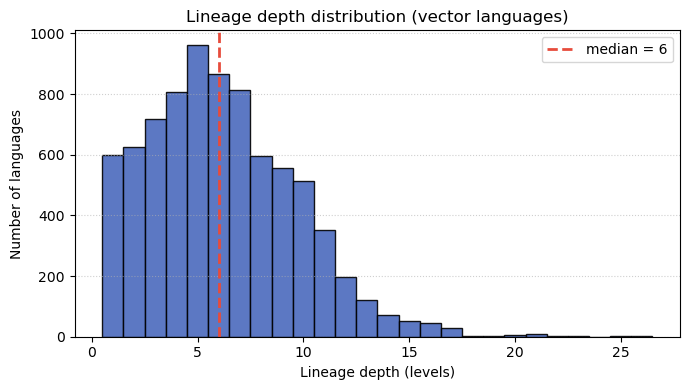

57.8% of vector languages with a lineage sit between 4 and 9 levels deep.
Only 32 languages exceed 17 levels.


In [10]:
max_depth = int(nonzero_depth.max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nonzero_depth, bins=np.arange(0.5, max_depth + 1.5, 1), color="#4a69bd",
        edgecolor="black", alpha=0.9)   # one bar centred on each whole depth
ax.axvline(nonzero_depth.median(), color="#e74c3c", linestyle="--", linewidth=2,
           label=f"median = {nonzero_depth.median():.0f}")
ax.set_xlabel("Lineage depth (levels)")
ax.set_ylabel("Number of languages")
ax.set_title("Lineage depth distribution (vector languages)")
ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_depth.png", dpi=300)
plt.show()

share_4_9 = nonzero_depth.between(4, 9).mean()
print(f"{share_4_9:.1%} of vector languages with a lineage sit between 4 and 9 levels deep.")
print(f"Only {(nonzero_depth > 17).sum()} languages exceed 17 levels.")

## 2.5 Largest Families Among the Vector Languages

The root family is the first item in each lineage.

In [11]:
# first item in the lineage tuple (the top-level family); None if the lineage is empty
df_vec["root"] = df_vec["lineage"].map(lambda v: lineage_parts(v)[0] if lineage_parts(v) else None)

top10 = df_vec["root"].value_counts().head(10)
top10.rename_axis("Family").to_frame("Vector languages")

,Vector languages
Family,
Atlantic-Congo,1377
Austronesian,1305
Indo-European,619
Sino-Tibetan,467
Afro-Asiatic,377
Nuclear Trans New Guinea,316
Pama-Nyungan,276
Bookkeeping,187
Otomanguean,186


**"Bookkeeping" is not a genuine language family.** It is a label Glottolog uses to retain codes
for languoids that turned out not to exist, or that are too poorly attested to classify. A
"Sign Language" label serves a similar function: Glottolog groups all sign languages under one
placeholder label because they are not related to one another by descent the way spoken-language
families are. Any analysis by family size should exclude both.

               all CSV rows  vector languages
Bookkeeping             385               187
Sign Language           344               139


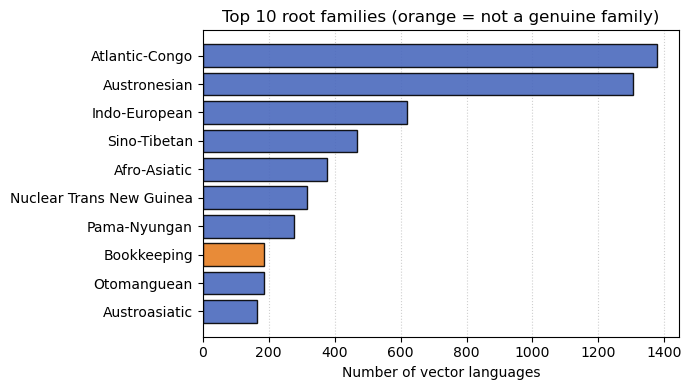

In [12]:
df["root"] = df["lineage"].map(lambda v: lineage_parts(v)[0] if lineage_parts(v) else None)

placeholder_roots = ["Bookkeeping", "Sign Language"]
print(pd.DataFrame({
    "all CSV rows": [(df["root"] == r).sum() for r in placeholder_roots],
    "vector languages": [(df_vec["root"] == r).sum() for r in placeholder_roots],
}, index=placeholder_roots))

top = top10[::-1]   # reversed so the largest is on top
colors = ["#e67e22" if name in placeholder_roots else "#4a69bd" for name in top.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top.index, top.values, color=colors, edgecolor="black", alpha=0.9)
ax.set_xlabel("Number of vector languages")
ax.set_title("Top 10 root families (orange = not a genuine family)")
ax.grid(axis="x", linestyle=":", alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_families.png", dpi=300)
plt.show()

## 2.6 Longitude Range Anomaly

Some rows store longitude as a value greater than 180 instead of using negative numbers. For
example, a language located in Maine, USA could be recorded at `291.34` instead of `-68.66`
(the same location, since `291.34 - 360 = -68.66`).

This does not affect the great-circle distance calculation (`getGreatCircleDistance()`) in
`_calculate_geocoord_vectors()`, since the underlying Haversine formula is unchanged by a full
360° shift. It would, however, affect any downstream code that plots these coordinates or
assumes a conventional −180°…180° range.

Geography vectors are built for the same vector languages as the phylogeny vectors, so the
figure is restricted to `df_vec`. The cell prints the out-of-range count for both the whole CSV
and the vector languages.

longitude outside -180..180 (all CSV rows): 3211 of 26229 with coordinates (12.2%)
longitude outside -180..180 (vector languages): 1257 of 7936 with coordinates (15.8%)


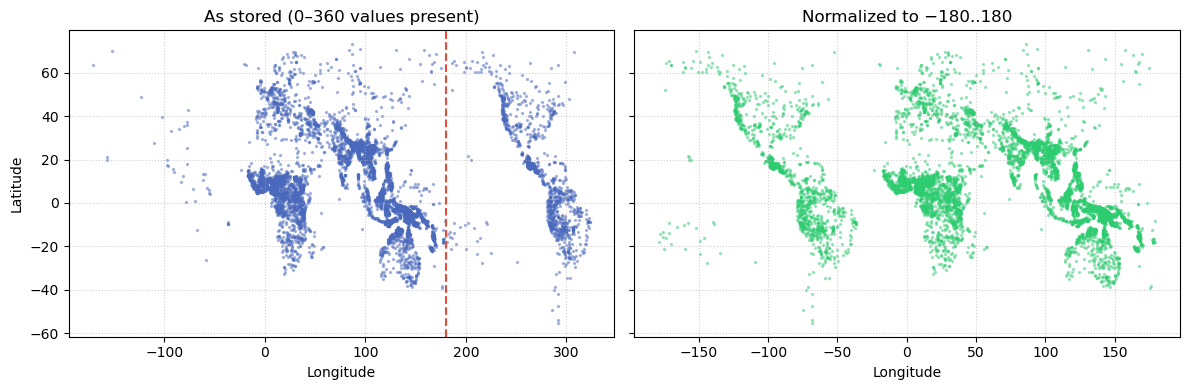

In [13]:
# how many rows use the 0-360 convention: whole CSV vs. vector languages only
for label, frame in [("all CSV rows", df), ("vector languages", df_vec)]:
    n_out = ((frame["longitude"] > 180) | (frame["longitude"] < -180)).sum()
    n_geo = frame["longitude"].notna().sum()
    print(f"longitude outside -180..180 ({label}): {n_out} of {n_geo} with coordinates ({n_out / n_geo:.1%})")

geo = df_vec.dropna(subset=["latitude", "longitude"]).copy()
geo["lon_norm"] = ((geo["longitude"] + 180) % 360) - 180   # same place, -180..180 range

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].scatter(geo["longitude"], geo["latitude"], s=2, alpha=0.4, color="#4a69bd")
axes[0].axvline(180, color="#e74c3c", linestyle="--")
axes[0].set_title("As stored (0–360 values present)")

axes[1].scatter(geo["lon_norm"], geo["latitude"], s=2, alpha=0.4, color="#2ecc71")
axes[1].set_title("Normalized to −180..180")

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.grid(linestyle=":", alpha=0.6)
axes[0].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_longitude.png", dpi=300)
plt.show()

Languages stored with longitude above 180 (right of the red line) appear detached from the rest
of the map on the left. After normalizing, the same points fall in their conventional positions
in the Americas on the right, which confirms this is a formatting difference, not a data error.

## 2.7 ISO 639-3 to Glottocode Mapping: `uriel_glottocode_map.csv`

This file has two columns, `iso_code` and `glottocode`. It is a translation table: given an
ISO 639-3 code (a separate, shorter language-code standard), it returns the matching Glottocode.

In [14]:
iso_map = pd.read_csv(ISO_MAP_PATH, dtype="string")
print("shape:", iso_map.shape)
print(iso_map.isna().sum())

no_glotto = iso_map[iso_map["glottocode"].isna()]
print(f"\n{len(no_glotto)} ISO codes have no matching Glottocode. First few:")
print(no_glotto["iso_code"].head(15).tolist())

shape: (7970, 2)
iso_code        1
glottocode    148
dtype: int64

148 ISO codes have no matching Glottocode. First few:
['alb', 'gre', 'mlg', 'ori', 'qqs', 'vsn', 'yid', 'est', 'ggo', 'leg', 'luy', 'mwd', 'ngo', 'wra', 'adc']


The ISO codes without a Glottocode are not a uniform group. Some are legacy ISO 639-2
bibliographic codes rather than true ISO 639-3 codes (`alb` and `gre`, for Albanian and Greek,
whose actual ISO 639-3 forms are `sqi` and `ell`; Library of Congress, n.d.). Others are genuine
ISO 639-3 "macrolanguage" codes that Glottolog represents only through their more specific member
varieties (`est`, `yid`; SIL International, n.d.). A few are special reserved codes for
non-language content, such as `zxx` ("no linguistic content"; SIL International, n.d.).

In [15]:
# Which of the codes named above are in the unmatched group?
named = ["alb", "gre", "est", "yid", "zxx"]
print({c: bool(c in set(no_glotto["iso_code"])) for c in named})

{'alb': True, 'gre': True, 'est': True, 'yid': True, 'zxx': True}


### 2.7.1 Glottocode format check on the mapping file

The same syntax rule from §2.2 is applied to this file's `glottocode` column as a completeness
check.

In [16]:
valid_codes = iso_map["glottocode"].dropna()
bad_codes = valid_codes[~valid_codes.str.match(glottocode_re)]

print("non-missing glottocodes:", len(valid_codes))
print("malformed glottocodes in the ISO map:", len(bad_codes))

non-missing glottocodes: 7822
malformed glottocodes in the ISO map: 0


### 2.7.2 Cross-file consistency check

This check determines whether the two data tables agree with each other.

In [17]:
map_ids = set(iso_map["glottocode"].dropna())
lfg_ids = set(df["language_id"])

print("glottocodes in the map file:", len(map_ids))
print("also found in lang_fam_geo.csv:", len(map_ids & lfg_ids))
print("in map file but missing from lang_fam_geo.csv:", len(map_ids - lfg_ids))
print("glottocodes reused by more than one ISO code:", valid_codes.duplicated().sum())

glottocodes in the map file: 7822
also found in lang_fam_geo.csv: 7822
in map file but missing from lang_fam_geo.csv: 0
glottocodes reused by more than one ISO code: 0


If nothing is missing, the two files agree completely, which is consistent with both having been
built from the same Glottolog snapshot rather than from two different versions. If no Glottocode
is reused, the mapping is strictly one-to-one.

## 2.8 Comparison with the Live Glottolog Database

This section did not rely on code run against a downloaded Glottolog database. Individual pages
on glottolog.org were consulted directly, and the classification each page displayed was compared
manually against the corresponding row in `lang_fam_geo.csv`.

| Item checked | Glottolog (live) | Result |
|---|---|---|
| Ghotuo (`ghot1243`) | Identical chain, confirmed via the page's internal classification path | Exact match |
| Slovincian (`slov1270`) | Glottolog's tree groups Slovincian under a node labelled "Kashubian" | Matches Glottolog (Wikipedia instead lists "Pomeranian"; the CSV agrees with Glottolog) |
| "Classical Indo-European" node | Confirmed as a current Glottolog grouping (code `clas1257`) | Confirmed |

Pages consulted (Hammarström et al., 2026):

- Ghotuo: https://glottolog.org/resource/languoid/id/ghot1243
- Slovincian: https://glottolog.org/resource/languoid/id/slov1270
- Classical Indo-European: https://glottolog.org/resource/languoid/id/clas1257

The cell below prints what the CSV holds for those three items so the comparison can be repeated
by hand against the pages above.

In [18]:
for code_id in ["ghot1243", "slov1270"]:
    row = df[df["language_id"] == code_id]
    if row.empty:
        print(f"{code_id}: not in lang_fam_geo.csv")
    else:
        r = row.iloc[0]
        print(f"{code_id} ({r['language_name']}):\n  {r['lineage']}\n")

n_classical = df["lineage"].fillna("").str.contains("Classical Indo-European", regex=False).sum()
print("rows whose lineage contains 'Classical Indo-European':", n_classical)

ghot1243 (Ghotuo):
  Atlantic-Congo, Volta-Congo, Benue-Congo, Akpes-Edoid, Edoid, North-Central Edoid, Afenmai-Bendel

slov1270 (Slovincian):
  Indo-European, Classical Indo-European, Balto-Slavic, Slavic, West Slavic, Lechitic, Kashubian

rows whose lineage contains 'Classical Indo-European': 3116


Automating this kind of check at scale would require Glottolog's full downloadable dataset
(published as a CSV/CLDF export), rather than the two smaller URIEL+ tables reviewed here, which
are summaries derived from Glottolog rather than Glottolog itself.

## 2.9 Summary

The cell below collects the headline results from the checks above into one table. Read the
values from that table rather than from prose, since they come straight from your data.

In [19]:
oob_all = ((df["longitude"] > 180) | (df["longitude"] < -180)).sum() / df["longitude"].notna().sum()
oob_vec = ((df_vec["longitude"] > 180) | (df_vec["longitude"] < -180)).sum() / df_vec["longitude"].notna().sum()

pd.Series({
    "Features in features.npz": num_features,
    "Largest feature category": f"{top_label} ({top_n / num_features:.1%})",
    "lang_fam_geo.csv rows": len(df),
    "Malformed glottocodes (lang_fam_geo)": len(bad),
    "Phylogeny nodes / edges": f"{n_nodes} / {n_edges}",
    "Matches URIEL+ expected 8887 / 8582": n_nodes == EXPECTED_NODES and n_edges == EXPECTED_EDGES,
    "Vector languages (rows in CSV)": len(df_vec),
    "Median lineage depth (vector langs)": nonzero_depth.median(),
    "Longitude > 180, all rows": f"{oob_all:.1%}",
    "Longitude > 180, vector langs": f"{oob_vec:.1%}",
    "ISO codes without a glottocode": len(no_glotto),
    "Map glottocodes missing from lang_fam_geo": len(map_ids - lfg_ids),
}, name="Result").to_frame()

,Result
Features in features.npz,593
Largest feature category,Syntax (51.8%)
lang_fam_geo.csv rows,26881
Malformed glottocodes (lang_fam_geo),0
Phylogeny nodes / edges,8887 / 8582
Matches URIEL+ expected 8887 / 8582,True
Vector languages (rows in CSV),8128
Median lineage depth (vector langs),6.0
"Longitude > 180, all rows",12.2%
"Longitude > 180, vector langs",15.8%


## 2.10 Takeaways

- **Identifier format:** both files can be checked against Glottolog's own naming rule without
  downloading anything (§2.2 and §2.7.1).
- **Node/edge counts:** the phylogeny tree derived from `lang_fam_geo.csv` should match what the
  URIEL+ code asserts (§2.3.1).
- **Family statistics** describe the vector languages, not every CSV row; the node and edge counts
  use the full CSV because the URIEL+ code does (§2.3.2).
- **Data-quality points:** the "Bookkeeping" and "Sign Language" labels are administrative
  categories rather than genuine language families (§2.5), and a share of longitude values are
  stored in the 0°–360° format rather than −180°…180° (§2.6).
- **Spot-checks** against the live Glottolog database (§2.8) were done by hand.

---

## References

- Hammarström, H., Forkel, R., Haspelmath, M., & Bank, S. (2026). *Glottolog 5.3* [Data set].
  Max Planck Institute for Evolutionary Anthropology. https://glottolog.org
- Glottolog. (n.d.). *Frequently asked questions*. GitHub.
  https://github.com/glottolog/glottolog/blob/master/faq.md
- Glottolog. (n.d.). *glottolog-cldf* [Data set]. GitHub. https://github.com/glottolog/glottolog-cldf
- Library of Congress. (n.d.). *ISO 639-2 codes for the representation of names of languages*.
  https://id.loc.gov/vocabulary/iso639-2.html
- SIL International. (n.d.). *ISO 639-3: Scope of denotation for language identifiers*.
  https://iso639-3.sil.org/about/scope
- Khan, A., Shipton, M., Anugraha, D., Duan, K., Hoang, P. H., Khiu, E., Doğruöz, A. S., & Lee,
  E.-S. A. (2025). URIEL+: Enhancing linguistic inclusion and usability in a typological and
  multilingual knowledge base. *Proceedings of COLING 2025*, 6937–6952.
- Shipton, M., Ng, Y. H., Khan, A., Hoang, P. H., Lu, X., Doğruöz, A. S., & Lee, E.-S. A. (2025).
  *Simple additions, substantial gains: Expanding scripts, languages, and lineage coverage in
  URIEL+* (arXiv:2510.27183). arXiv. https://arxiv.org/abs/2510.27183